# CAB420 Classification, Bonus Example: XGBoost
Dr Simon Denman (s.denman@qut.edu.au)

### What is a "Bonus" Example?

These are extra examples that cover content outside the scope of CAB420. It exists becuase of one or more of the following reasons:
* It's closely related to other stuff we're looking at and I wanted to include it, but the course has too much content already, so I punted it here; 
* It's interesting;
* Someone (probably multiple someones if I wrote an example) has asked a question about it before.

You can freely ignore this example if you want. You really don't have to be reading this. You could go outside, go read a book, have a nap, take up a hobby, whatever you want really. The point I want to make here **this example really is optional**. Things here won't appear on an exam, or in an assignment (though you could use this in an assignment if you wanted). But if you're interested, this is here, and if you're reading this, so are you. 

Some things to note with bonus examples:
* These may gloss over details that elsewhere get more coverage. I may skip plots I'd normally include, or gloss over other details. The expecatation is that if you're reading this, you've looked at all the "core" examples and are comfortable with what they're doing. 
* Some bits of code might not be as well explained or explored as you're used to in the other examples. These examples are here for interested students looking to extend their knowledge, and I'm assuming if you're here, you're comfortable figuring code out, debugging stuff, and generally googling about to help work out what something is doing.
* There's no Tl;DR section at the top. If you're here, I'm assuming it's because you're interested and want all the gory details and don't just need the quick summary at the top.
* While my regular examples (the "core" ones) certainly contain their fare share of silly remarks and typos, expect the level of flippancy and the prevalence of typos increase in a bonus example. 

That said, as always, if you are stuggling to follow what I've got in here please shoot me a message. The aim is still for this to be clear enough to follow afterall.

## Overview

Gather round [extreme sports lovers](https://en.wikipedia.org/wiki/Extreme_ironing), as we take a look at eXtreme Gradient Boosting, or XGBoost for short.

XGBoost is one that comes up quite a bit outside of the main stuff in CAB420, mainly because it's been used to win just about every kaggle contest using structured data (i.e. tabular data). 

XGBoost is, at it's core, a decision tree based method, in particular an implementation of Gradient Boosted Decision Trees (GBDT - yes, it's another bloody acronym). Like Random Forests, it trains an ensemble of trees - because more is better. But whereas random forests aim to train totally uncorrelated trees through bagging, XGBoost uses this other b-word: *boosting*. 

The idea behind boosting is that you create a single strong model by combining multiple weak models. *Gradient boosting* follows this same idea, but uses the gradient of the error on some objective function to guide the creation of additional later trees in the ensemble. The process will iterative train an ensemble of shallow decision trees, where each iteration uses the error residuals of the previous model to fit the next. Once all trees are trained, the final prediction is a weighted sum of all tree predictions. If we compare this to our random forest, the bagging mechanism there will minimise the variance and reduce overfitting, while the boosting approach will minimise the bias and underfitting. Sticking with the random forest comparision, with our random forests as each tree is totally independent from all others, they can be trained quite fast and in parallel. For GBDT, trees are build sequentially, as the error from previous trees informs the training of the next one.

Now for the [extreme](https://www.youtube.com/watch?v=7fd6NBQ8ego) part, XGBoost is a highly optimised and very scalable implementation of gradient boosted decision trees. Trees are still trained sequentially, but through lots of very clever code optimisations each individual tree can be trained in a distributed manner. This is of most benefit on large datasets where you've got enough data to distribution across several cores (or even a GPU or a cluster), so on the data we're going to use in this example we're unlikely to see a huge gain from all that, but you should still get the idea of how to use XGBoost if you wish to.

### Where does this fit into all the other CAB420 content?

This fits alongside our other classification content, most naturally alongside random forests as another ensemble learning method. With the gradient descent based optimisation there are also some clear links with methods such as SVMs and Deep Learning models.

In [1]:
import xgboost as xgb
import shap
import pandas
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import re
import string
import numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import sklearn.metrics

## Data Preperation

We're going to use the titanic dataset today. This is partial passenger manifest, which contains some info like what a passenger's fare was and what passenger class they were travelling in, their age, gender, the number of parents and children they had travelling with them, and how many siblings and spouses they had with them (I'm not sure if this means that there were poligamists on the boat or not, but let's assume that there were), and finally, if they lived or died.

The task with this data is to predict that last one - did they get back to shore alive.

For out data prep, we'll convert the passenger class and gender into categoricals, and leave the other columns alone. We'll then split out data into train and test, and then we're ready to go.

In [2]:
titanic = pandas.read_csv('../data/titanic.csv')
titanic['Pclass'] = pandas.Categorical(titanic.Pclass)
titanic['Sex'] = pandas.Categorical(titanic.Sex)

X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## XGBoost

Let's just get into it and train a model. I'm going to use default settings here, and we'll see what happens. The only thing I'll set is `enable_categorical=True` as we have categorical datatypes that we'd like to use properly.

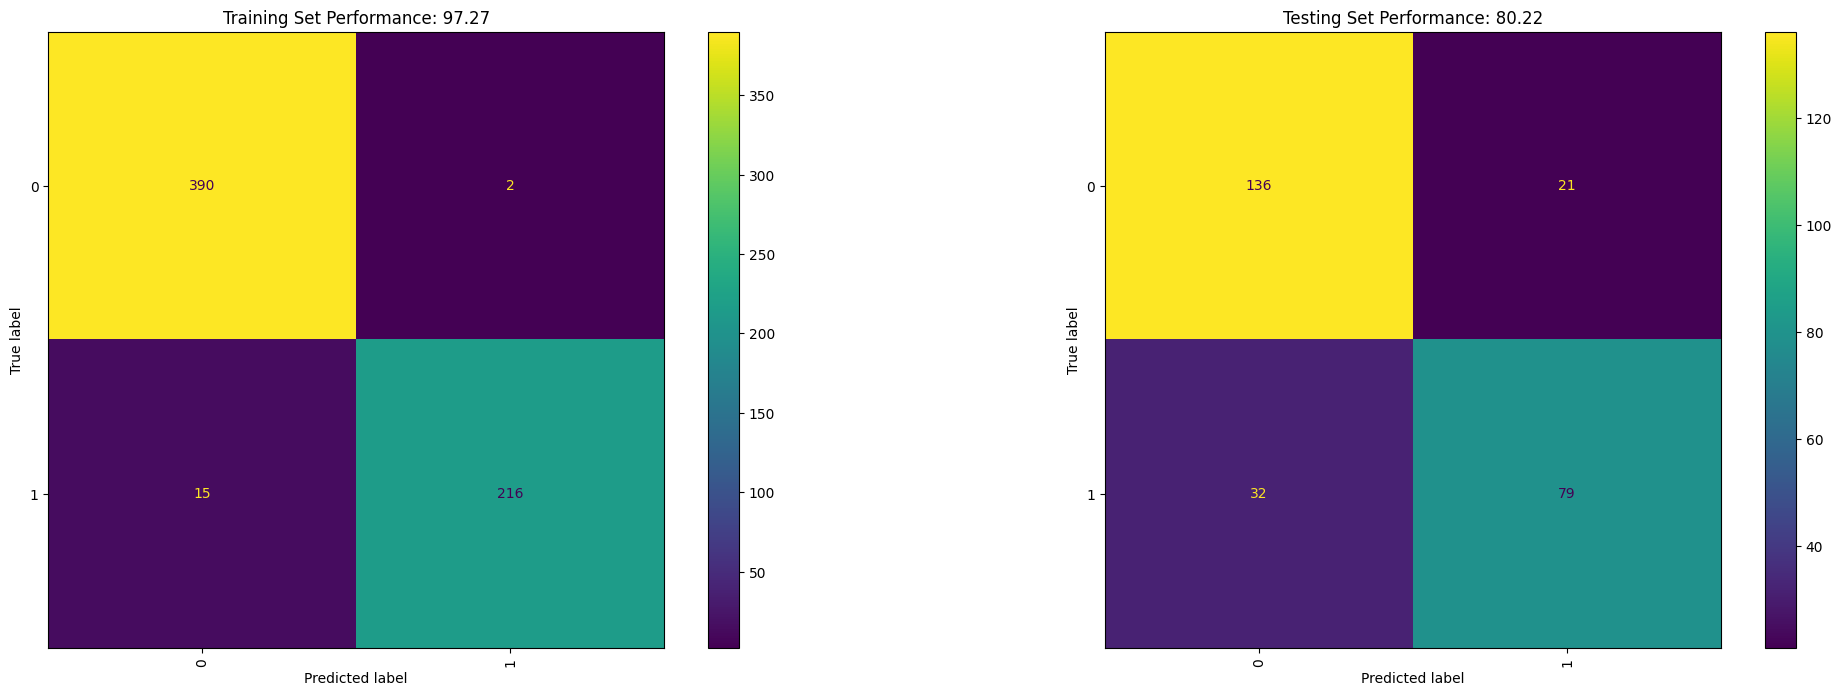

In [3]:
model = xgb.XGBClassifier(enable_categorical=True, random_state=42)
model.fit(X_train, y_train)

def eval_model(model, X_train, Y_train, X_test, Y_test):
    fig = plt.figure(figsize=[25, 8])
    ax = fig.add_subplot(1, 2, 1)
    pred = model.predict(X_train)
    conf = ConfusionMatrixDisplay.from_predictions(Y_train, pred, normalize=None, xticks_rotation='vertical', ax=ax)
    conf.ax_.set_title('Training Set Performance: %1.2f' % (100.0*numpy.sum(pred == Y_train)/len(Y_train)));
    ax = fig.add_subplot(1, 2, 2)
    pred = model.predict(X_test)
    conf = ConfusionMatrixDisplay.from_predictions(Y_test, pred, normalize=None, xticks_rotation='vertical', ax=ax)
    conf.ax_.set_title('Testing Set Performance: %1.2f' % (100*numpy.sum(pred == Y_test)/len(Y_test)));

eval_model(model, X_train, y_train, X_test, y_test)

From the above, that works quite well. We see some overfitting, but test performance of about 80% is not bad for a first try.

In terms of tweaking performance, XGBoost has a lot of parameters and options to maximise things. Covering all possible options here is not going to happen, but we'll look at a selection that are one or more of:
* Important
* Similar in style/meaning to one's we've seen with other methods
* Easy to understand

If you want to full breakdown on options, [the documentation is a great place to look](https://xgboost.readthedocs.io/en/stable/parameter.html)

First up, I'm going to create a function to evaluate a single parameter over a range of values to make the following a bit easier to run.

In [4]:
# X_train, y_train, X_test, y_test - training and testing data
# param_name - name of parameter to manipulate as a string
# param_range - list of values to use
# line - boolean indicating whether to draw plots as a line plot
# x_log - should the x-axis have a log scale?
# base - if the x-axis is a log scale, what should the base be?
# additional_params - any other parameters we want to set, provided as a dictionary
def eval_param(X_train, y_train, X_test, y_test, param_name, param_range, line=True, x_log=False, base=10, additional_params = {}):
    # f1 scores for train and test sets
    f1_train = []
    f1_test = []

    # iterate over parameter range
    for p in param_range:
        # fit a model, note that we build a simple dictionary to pass in the parameter value in question
        # as we've already got a dictionary coming in from the input, just add to that
        additional_params[param_name] = p
        model = xgb.XGBClassifier(enable_categorical=True, **additional_params, random_state=42)
        # fit the model
        model.fit(X_train, y_train)
        # get some F1s
        f1_train.append(sklearn.metrics.f1_score(y_train, model.predict(X_train)))
        f1_test.append(sklearn.metrics.f1_score(y_test, model.predict(X_test)))

    # time to plot stuff
    fig = plt.figure(figsize=[8, 3])
    ax = fig.add_subplot(1, 1, 1)
    # plot training and testing performance as either a line or scatter plot
    if (line):
        ax.plot(param_range, f1_train, label='Training F1')
        ax.plot(param_range, f1_test, label='Testing F1')
    else:
        ax.scatter(param_range, f1_train, label='Training F1')
        ax.scatter(param_range, f1_test, label='Testing F1')

    # set x-axis to a log scale if desired
    if (x_log):
        ax.set_xscale('log', base=base)

    # write some stuff on the plot
    ax.legend()
    ax.set_title('Performance as %s varies' % param_name)
    ax.set_xlabel(param_name)
    ax.set_ylabel('F1 Score')

First up, some parameters we know well:
* The maximum depth of the trees
* The number of estimators

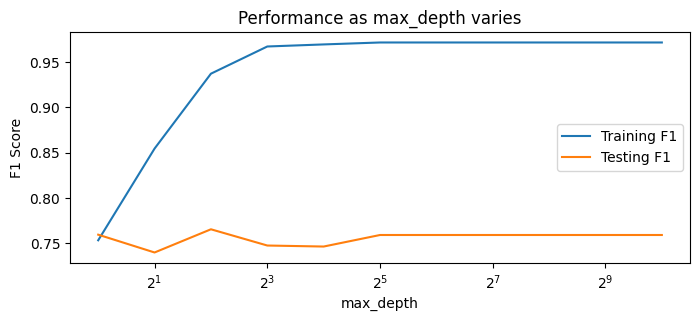

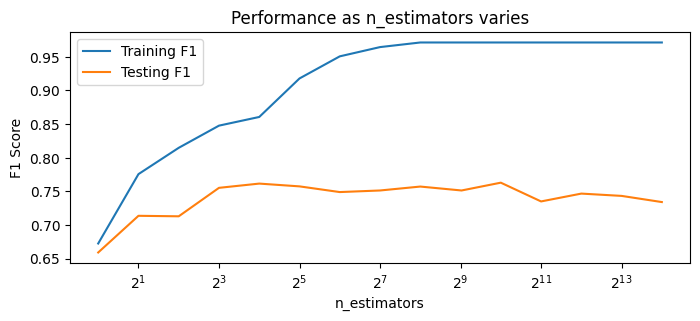

In [5]:
eval_param(X_train, y_train, X_test, y_test, 'max_depth', [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], x_log=True, base=2, additional_params={})
eval_param(X_train, y_train, X_test, y_test, 'n_estimators', [1, 2, 4, 8, 16, 32, 64, 128, 256, 521, 1024, 2048, 4096, 8192, 16384], x_log=True, base=2, additional_params={})

`max_depth` behaves pretty similar to what we see with a random forest: more depth means more power to separate things, and leads to more overfitting. With this data, we see a depth of 3 is actually best on the test set.

`n_estimators` is similar to it's random forest counterpart up to a point. With an RF, generally a bigger forest is if not better, then at least no worse than a smaller forest. Adding trees won't cause any more overfitting, we may well just see that there's no real benefit to going any bigger as we've already got enough diversity in the ensemble. For XGBoost, because trees are trained sequentially with the errors from earlier trees informing later training updates, we see training accuracy continues to creep ever higher as we add more and more trees. For our testing accuracy, that increases up to some point after which we start to overfit. What we need is some way to stop adding trees once peformance stops improving - more on that later.

Next up is our learning rate. Is a weight (from [0..1]) applied to the feature weights after each boosting step. Basically, it will shrink feature weights after each tree, making the whole process more conservative. As this is applied after each boosting step (i.e. after each tree is built), changing the number of boosting steps/trees will change the sort of thing that we see, so we'll consider two different ensemble sizes here.

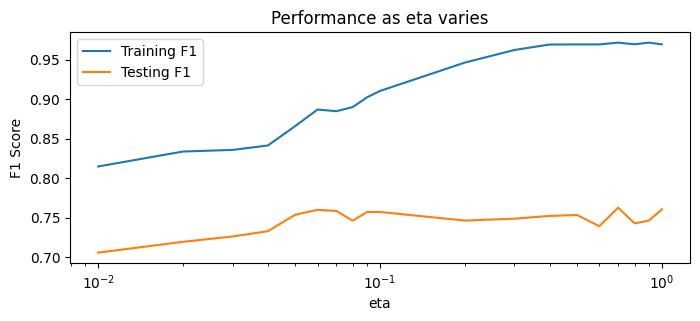

In [6]:
eval_param(X_train, y_train, X_test, y_test, 'eta', 
           [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], x_log=True, 
           additional_params={'n_estimators':100})

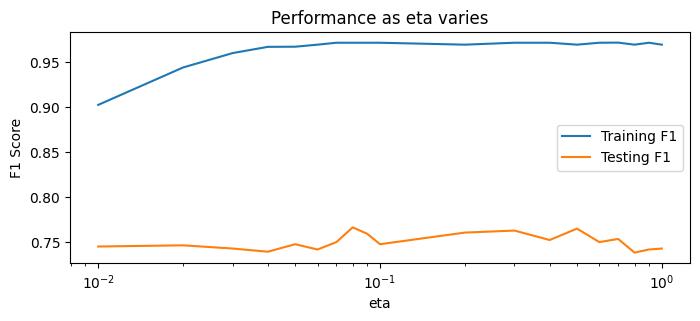

In [7]:
eval_param(X_train, y_train, X_test, y_test, 'eta', 
           [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], x_log=True, 
           additional_params={'n_estimators':1000})

We see some quite difference performance going on. With the smaller ensemble (top plot), the higher values of learning rate are better, and performance keeps increasing. If we consider what happens here, `eta=1` means that no feature shinkage is applied after each tree is built, so in the smaller ensemble where there are fewer boosting rounds, allowing each tree more discriminative power helps. For the larger tree, a more conservative setting works better and setting this too high leads to overfitting.

Next up are some regularisation parameters. We have `reg_alpha` and `reg_lambda`, which are simply L1 and L2 regularisation terms like LASSO and Ridge. These are applied to the feature weights, and do similar things to what we see in regression. Namely:
* Increasing the L1 regularisation parameter will lead to increased sparsity (i.e. more weights being set to 0)
* Increasing the L2 regularisation parameter will lead to weights being shrunk, and will avoid having huge individual weights, but will not push weights to 0

We can have both the L1 and L2 weights active too - but we'll not worry about that here.

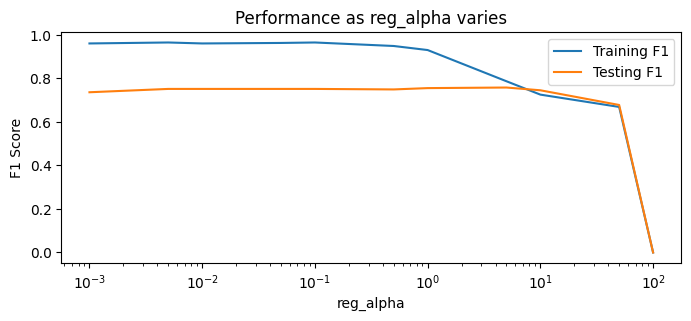

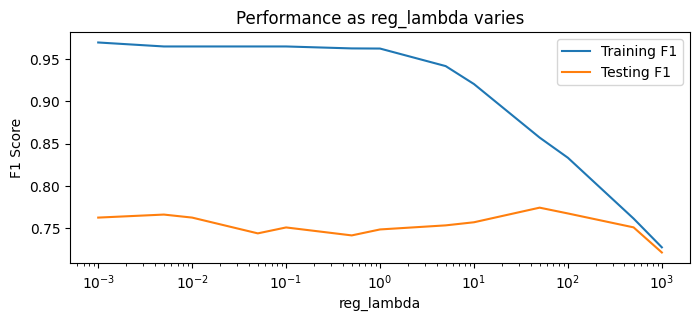

In [8]:
eval_param(X_train, y_train, X_test, y_test, 'reg_alpha', [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100], x_log=True, additional_params={})
eval_param(X_train, y_train, X_test, y_test, 'reg_lambda', [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000], x_log=True, additional_params={})

Results wise, we see the same sort of shape in these plots that we see with our regression models. Training accuracy goes down as we increase either regularisation parameter. Our testing accuracy (or validation accuracy if we were using a validation set) goes up a bit as we add some regularisation, but then goes down once we add too much and over-regularise our model. For L1, we see that this over regularisation can also be a bit catastrophic, with accuracy falling rather sharply to 0 once we see the L1 weight too big.

As per linear regression (and any other method where we can use regularisation), regularisation is not guaranteed to improve results, but will trade off between variance and bias.

Let's get into some slightly odder parameters now. First up, `grow_policy`, which controls how the trees themselves grow. Generally in a decision tree, we'll see trees grow somewhat uniformly, where all branches will reach similar depths and branching will stop once the maximum depth is reached. This behaviour is actived by the `depthwise` option here, which is the default - so we'll ignore that. Our second choice is `lossguide`, which will now make splits in the tree at whichever node will lead to the largest decrease in the loss function. This will ignore the maximum depth parameter and can lead to very deep and uneven trees. Growth will instead stop when a maximum number of leaves in the tree is reached. Let's see what happens when we play with that.

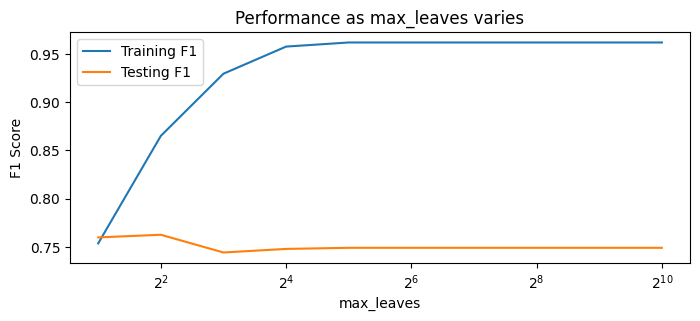

In [9]:
eval_param(X_train, y_train, X_test, y_test, 'max_leaves', [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], x_log=True, base=2, 
           additional_params={'grow_policy' : 'lossguide'})

The overall shape of the above plot is simlar to what we see as we increase the tree depth. More leaves means trees can go deeper, so as we increase that we see an initial gain in performance on both the training and testing sets, but then overfitting kicks in.

The most noteworthy difference is perhaps that we achieve best performance at a lower value of `max_leaves` than we do for `tree_depth` (when using the `depthwise` approach). This is because with the `lossguide` approach we tend to create more asymetrical tress, where some braches will go very deep to minimise the loss while others may not. This, essentially, can allow us to overfit faster. I will stress, this does not mean that `lossguide` is a worse option - there will be cases where you have very clear indicator variabales that do a great job of separating one class (or part of one class) and so having further splits under that node might not make more sense - it may be far better in those settings to focus on the areas of the tree where there is more confusion. As always, what works best will vary from one dataset to the next.

Let's now consider the objective function that we're asking XGBoost to minimise. We have three options, and we're going to put some maths down for these too so that we can try to explain what's going on. For all of these, we're going to try and use some common notation. In particular, $y$ is our class label, and $\hat{y}$ is our prediction.

#### Hinge Loss

For a single sample, defined as

$\max(0, 1 - y \hat{y})$. 

Here, $y$ is either $+1$ of $-1$, and our prediction is in the range $[-\infty..\infty]$. To consider what happens to the loss, let's look at a few scenarios:
* If $\hat{y} = 1$, and $y=1$, then we have $\max(0, 1 - 1 \times 1) = 0$. This makes sense, the model got it right, the loss should be 0.
* If $\hat{y} = 2$, and $y=1$, then we have $\max(0, 1 - 1 \times 2) = \max(0, -1) = 0$. Our model is now super correct and confident, but the loss is still just 0. There's no bonus for being more correct.
* If $\hat{y} = -0.5$, and $y=1$, then we have $\max(0, 1 - 1 \times -0.5) = \max(0, 1 + 0.5) = 1.5$. Our model is wrong here, so we have recorded a loss. Again, makes sense.
* If $\hat{y} = -2.5$, and $y=1$, then we have $\max(0, 1 - 1 \times -2.5) = \max(0, 1 + 2.5) = 3.5$. Our model is really wrong here, and our loss starts to get big as a result. Big errors will attract big penalties.

So hinge loss will penalise big errors, and the more wrong our model is, the bigger the error. Hinge loss if what's used in an SVM, and you can think about this process as trying to encourage decisions to lie the right side of the boundary, with some margin of separation. Once things are on the correct side (with a bit of a margin) there's no great concern in trying to optimise further, but there are big penalties for having things on the wrong side of the boundary. Training with hinge loss will also mean that our model outputs are set to 0 or 1.

#### Logistic Loss 

For a single sample, defined as

$-(y \log(\hat{y}) + (1 – y) \log(1 –\hat{y}))$.

Here, $y$ is either $1$ of $0$, and our prediction is in the range $[0..1]$. Prior to sending our model outputs to the logistic loss function, they are passed through a sigmoid function which will squish them into the range $[0..1]$. The sigmoid function will push large negative numbers close to 0, and large positive numbers close to 1. Let's consider a few examples of what the loss function does:
* If $\hat{y} = 1$, and $y=1$, we have $-(1 \log(1) + (1 – 1) \log(1 – 1)) = 0$. We're correct, the loss is 0.
* If $\hat{y} = 0.5$, and $y=1$, we have $-(1 \log(0.5) + (1 – 1) \log(1 – 0.5)) = 0.3$. We're essentially half right, so we record a loss, but not a huge one.
* If $\hat{y} = 0.1$, and $y=1$, we have $-(1 \log(0.1) + (1 – 1) \log(1 – 0.1)) = 1$. We're wrong, and the loss function says so.
* If $\hat{y} = 0.01$, and $y=1$, we have $-(1 \log(0.01) + (1 – 1) \log(1 – 0.01)) = 2$. We're really wrong, and the loss is bigger again.

Compared to hinge loss, we're certainly still penalising incorrect decisions (as we should), but really bad decisions aren't penalised to the same extent that hinge loss does. In practice too, our $\hat{y}$'s are never going to be exactly 0 or 1, so even for correct decisions there will be a small penalty, where as for hinge loss once we've got things correct enough the loss drops to 0. However, with logistic loss our model outputs will be in $[0..1]$, so we have some freedom to adapt the threshold if we want.

#### Raw Logit Loss

Fundamentally very similar to the logitic loss above. I can't find the exact loss equation being used, but the XGBoost help say it's "logistic regression for binary classification, output score before logistic transformation", which implies it's fundamentally the same loss as the logistic loss, but the results that are output are simply the raw logit scores prior to the sigmoid function.

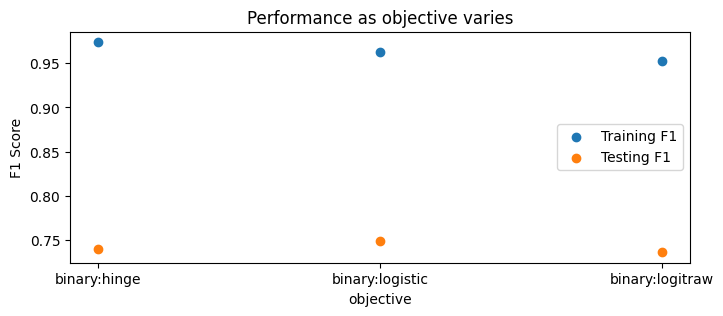

In [10]:
eval_param(X_train, y_train, X_test, y_test, 'objective', ['binary:hinge', 'binary:logistic', 'binary:logitraw'], line=False, additional_params={})

Given all the maths above, you may have been expecting something more dramatic. Sorry. In this case it doesn't make much difference, and to be honest, you're not going to see a huge change across these in most cases as they are doing very similar things. What is perhaps the biggest difference between those three is not captured by the above at all. 

Consider the following:

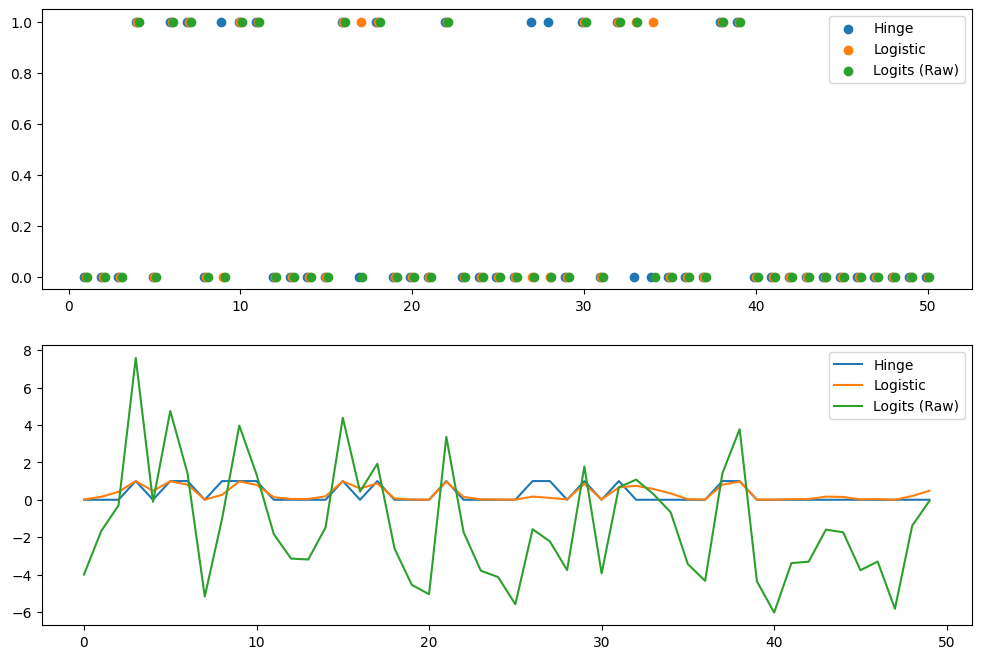

In [11]:
model = xgb.XGBClassifier(grow_policy='depthwise', n_estimators = 100, enable_categorical=True, objective='binary:hinge').fit(X_train, y_train)
hinge_pred = model.predict(X_test)
hinge_pred_proba = model.predict_proba(X_test)
model = xgb.XGBClassifier(grow_policy='depthwise', n_estimators = 100, enable_categorical=True, objective='binary:logistic').fit(X_train, y_train)
logistic_pred = model.predict(X_test)
logistic_pred_proba = model.predict_proba(X_test)
model = xgb.XGBClassifier(grow_policy='depthwise', n_estimators = 100, enable_categorical=True, objective='binary:logitraw').fit(X_train, y_train)
logit_raw_pred = model.predict(X_test)
logit_raw_pred_proba = model.predict_proba(X_test)

fig = plt.figure(figsize=[12, 8])
ax = fig.add_subplot(2, 1, 1)
ax.scatter(numpy.linspace(0.9, 49.9, 50), hinge_pred[0:50], label='Hinge')
ax.scatter(numpy.linspace(1, 50, 50), logistic_pred[0:50], label='Logistic')
ax.scatter(numpy.linspace(1.1, 50.1, 50), logit_raw_pred[0:50], label='Logits (Raw)')
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.plot(hinge_pred_proba[0:50, 1], label='Hinge')
ax.plot(logistic_pred_proba[0:50, 1], label='Logistic')
ax.plot(logit_raw_pred_proba[0:50, 1], label='Logits (Raw)')
ax.legend()

What we see is the following:
* Hinge loss outputs either 0 or 1
* Logistic loss outputs a value between 0 and 1. Nominally a threshold of 0.5 is used to make classification decisions, but really you could use any threshold here. This output can give you a sense of model confidence as well as the actual decision.
* Logits are the raw logit scores, so are unbounded. This also gives a sense of confidence, but the scale is a bit more ambiguous.

It's important to note that these losses are just for the binary classification case. For multi-class classification, or regression, you'd get a different set of loss options. Consult [the documentation](https://xgboost.readthedocs.io/en/latest/parameter.html) for more details.

## Importance Plots

One other nice feature XGBoost offers is that it's somewhat interpretable. There's an inbuilt function to plot the importance of features, but the type of importance you plot has a big impact on what is shown:

<Axes: title={'center': 'Feature Importance, Cover'}, xlabel='F score', ylabel='Features'>

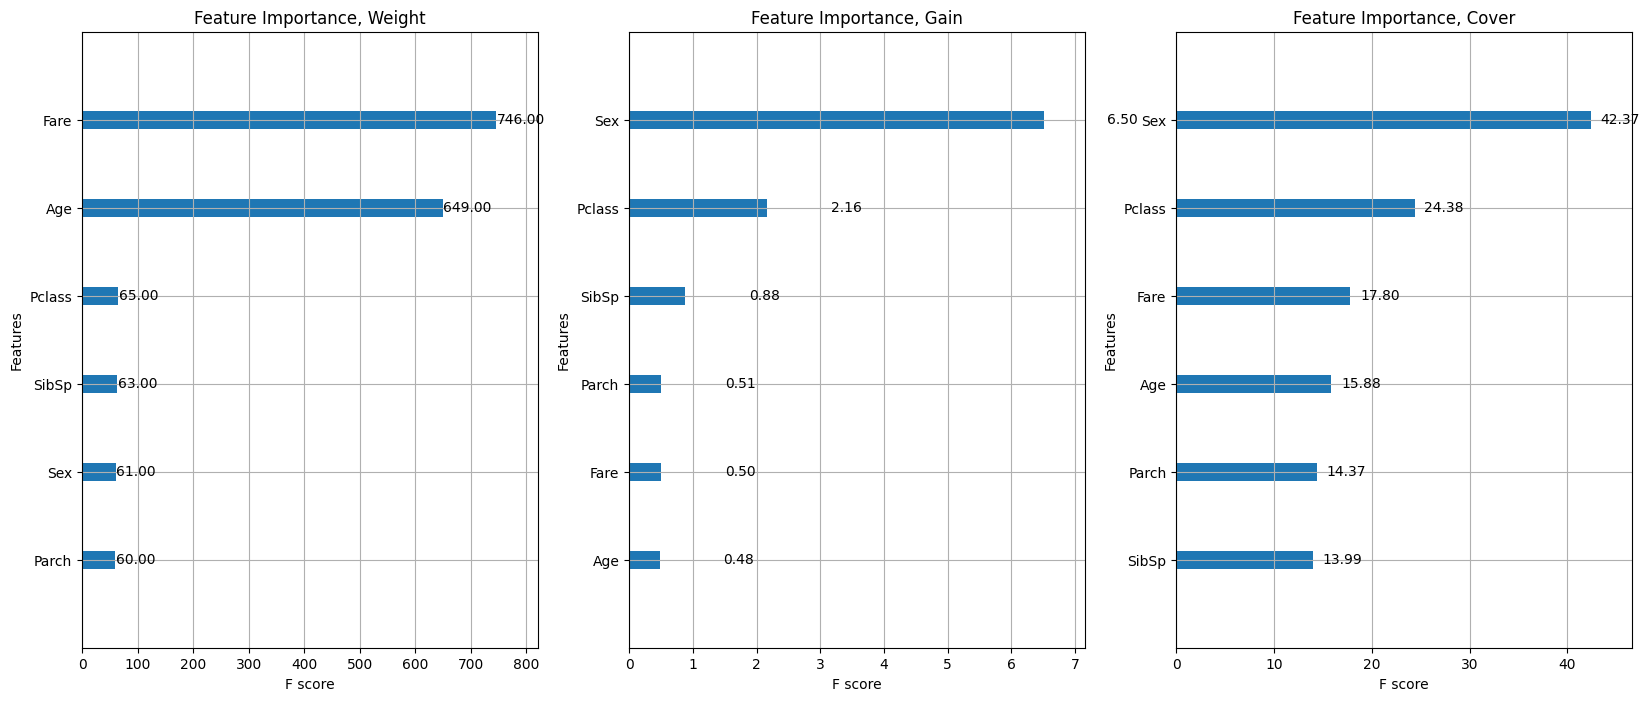

In [12]:
fig = plt.figure(figsize=[20, 8])
ax = fig.add_subplot(1, 3, 1)
xgb.plot_importance(model, ax=ax, importance_type='weight', max_num_features=10, title='Feature Importance, Weight', values_format='{v:.2f}')
ax = fig.add_subplot(1, 3, 2)
xgb.plot_importance(model, ax=ax, importance_type='gain', max_num_features=10, title='Feature Importance, Gain', values_format='{v:.2f}')
ax = fig.add_subplot(1, 3, 3)
xgb.plot_importance(model, ax=ax, importance_type='cover', max_num_features=10, title='Feature Importance, Cover', values_format='{v:.2f}')

Here we have three different stories being told:
* First up, using `weight` as the importance type considers how many trees a feature appears in. The idea being that if a feature is used in more trees, it must be more useful. Here, we see fare and age dominate.
* Next up, `gain` considers the average gain of splits that use the feature. Higher values indicate that when this feature is used to make a split, the results are better in terms of separating the classes. Here, sez and passenger class win.
* Finally, `cover` is average coverage of splits which use the feature. The coverage is the number of samples affected by the split, so higher values indicate that when it's used, it's quite impactful. Here sex and passenger class win out again, but overall it's much closer.

It's fair to say the above is somewhat ambiguous, but it is at least fair to say that the "siblings and spouses" and "parents and children" variables aren't that important.

### SHAP Values

Because we can, we'll quickly look at one other way to try make sense or the above. We're going to pull out the Shapley values, which come from game theory. These look at the individual contribution of each feature towards the final output.

SHAP values can be slow to comptue for large models and/or large datasets, but this model and data is quite small, so this is quite fast. 

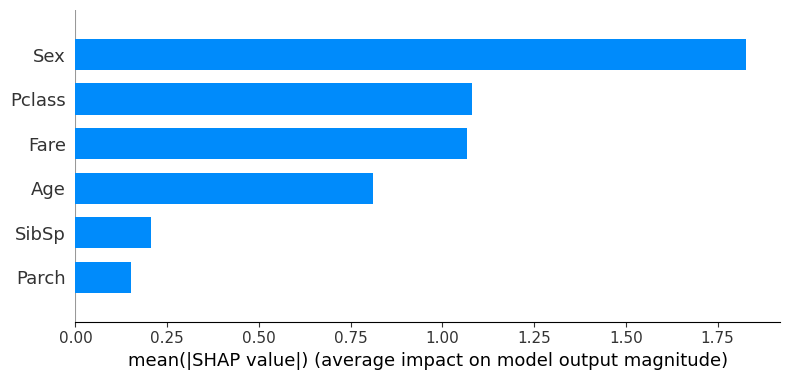

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

What we see is something perhaps in-between what we saw above. Gender, fare, age and passenger class are all quite important, while the siblings and sposes and parents and children variables don't offer much. 

SHAP also allows us to look at individual samples understand what is contributing towards the decisions made for those samples. Note that the SHAP package doesn't seem to know quite what to do with categorical variables, but for the continuous variables we can get a sense of how they contribute towards the final decision

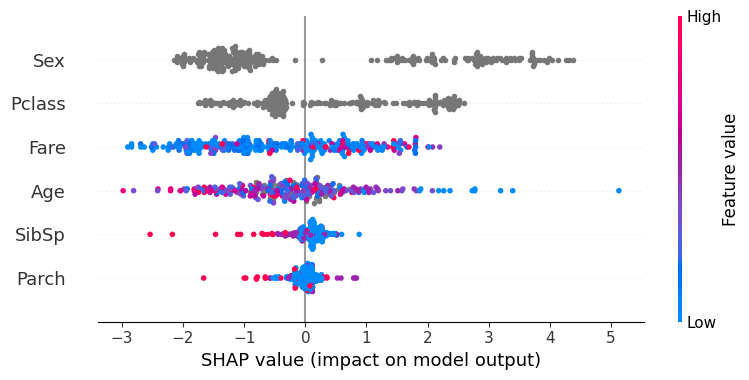

In [14]:
shap.summary_plot(shap_values, X_test)

There's lots of other stuff you can get out of SHAP values if you wish (see the [documentation](https://shap.readthedocs.io/en/latest/)), but we'll leave this here for now.

## Final Thoughts

This example has looked at XGBoost, which is one of the most popular non-deep learning models out there. In a lot of respsect, XGBoost is not so much a model as a library that offers a hyper-efficient implementation of gradient boosted decisions trees, with a huge number of bells and whistles. XGBoost is particularly well suited to tabular data, and frequently outperforms most approaches (including deep learning models) on this data. 

At it's core however, XGBoost is just a boosted decision tree implementation and thus the models that it learns are just a set of trees. This may seem similar to a random forest (and in a lot of respects it is), but where as with a random forest trees are run in parallel and decisions are obtained by averaging what comes out of each tree, in XGBoost they are run one after the other. The rationale behind a random forest is to have lots of uncorrelated classifiers, and then as long as they can perform at better than chance, by aggregrating their decisions the overall result can be improved. For XGBoost, we have a series of weak classifiers that build on top of each other, gradually refining model estimates. The end result in both models is a lot of trees, but they are used in different ways.

Like random forests, you have similar parameters such as the tree depth (or number of leaves, if you build trees different ways), and the number of trees (estimators), and the impact of these is fairly similar to what we see in a random forest (perhaps less so for the number of trees). Beyond these parameters though, you have a lot of other options you can access to. There are parameters to control how subsequent trees in the boosted ensemble are built, what regularisation is applied, how trees are grown, and the loss that is used.

As if often the case, providing hard recommendations of what you set parameters to is not easy. This will vary wildly depending on the data, and the nature of the problem you're exploring - consulting the [documentation](https://xgboost.readthedocs.io/en/latest/parameter.html), and being willing to play around, explore, and do some further reading, are highly recommended if you want to get serious about applying this approach.